uv add langchain langchain-openai langchain-community langchain-chroma langchain-huggingface langgraph sentence-transformers chromadb pypdf feedparser apscheduler duckduckgo-search reportlab python-dotenv

In [1]:
import os
import re
import json
import time
import sqlite3
import requests
import datetime
import feedparser

from pathlib import Path
from dotenv import load_dotenv
from typing import TypedDict, List, Optional

from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langgraph.graph import StateGraph, END
from langchain.agents import create_agent
from apscheduler.schedulers.background import BackgroundScheduler
from ddgs import DDGS

from IPython.display import Image, display

# Imports pour ReportLab (Génération PDF)
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus.tables import Table, TableStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

print("Imports terminés")

c:\Users\DELL\Desktop\Cellule SMA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\DELL\Desktop\Cellule SMA\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Imports terminés


In [2]:
load_dotenv()

OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE = "https://openrouter.ai/api/v1"

TARGET_TOPIC = """
roadmap IA,
budget IA,
stack technique,
hallucinations,
RAG,
LangGraph,
AutoGen,
projets IA,
gouvernance,
infrastructure
"""

REPORTS_DIR = "reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

print("Configuration terminée")

Configuration terminée


In [3]:
fast_model = ChatOpenAI(
    model="openai/gpt-oss-20b:free",
    #openai/gpt-oss-20b:free
    #nvidia/nemotron-nano-12b-v2-vl:free
    openai_api_key=OPENROUTER_KEY,
    openai_api_base=OPENROUTER_BASE,
    temperature=0.2,
    max_tokens=1200
)

reasoning_model = ChatOpenAI(
    model="openai/gpt-oss-120b:free",
    #openai/gpt-oss-120b:free 
    #nvidia/nemotron-3-super-120b-a12b:free 
    #nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
    openai_api_key=OPENROUTER_KEY,
    openai_api_base=OPENROUTER_BASE,
    temperature=0.1,
    max_tokens=2500
)

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"}
)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200
)

print("LLMs et Embeddings initialisés")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3925.65it/s]


LLMs et Embeddings initialisés


In [4]:
INTERNAL_DOCS_DIR = Path("data/internal_docs")
loader = PyPDFDirectoryLoader(INTERNAL_DOCS_DIR)
internal_docs = loader.load()

internal_chunks = []
for doc in internal_docs:
    chunks = splitter.split_documents([doc])
    for chunk in chunks:
        chunk.metadata["source_file"] = doc.metadata.get("source", "unknown")
        chunk.metadata["document_type"] = Path(doc.metadata.get("source", "")).stem
        internal_chunks.append(chunk)

print(f"Docs internes : {len(internal_docs)}")
print(f"Tranches internes : {len(internal_chunks)}")

internal_db = Chroma.from_documents(
    documents=internal_chunks,
    embedding=embedding_model,
    persist_directory="chroma_internal",
    collection_name="internal_knowledge"
)

print("Chroma interne initialisée")

Docs internes : 5
Tranches internes : 10
Chroma interne initialisée


In [5]:
# Tool GitHub 
@tool
def github_trends(query: str):
    """Recherche GitHub trends avec gestion des erreurs."""
    url = "https://api.github.com/search/repositories"
    params = {"q": query, "sort": "stars", "per_page": 5}
    try:
        r = requests.get(url, params=params)
        data = r.json()
        if "items" not in data:
            return f"Erreur API GitHub ou aucun résultat : {data.get('message', 'Inconnu')}"
            
        outputs = []
        for repo in data["items"][:5]:
            outputs.append(
                f"Repository: {repo.get('full_name', 'N/A')}\n"
                f"Description: {repo.get('description', 'N/A')}\n"
                f"Stars: {repo.get('stargazers_count', 'N/A')}\n"
            )
        return "\n".join(outputs)
    except Exception as e:
        return f"Erreur lors de la connexion à GitHub : {str(e)}"

# Tool ArXiv
@tool
def arxiv_search(query: str):
    """Recherche papers récents sur arXiv."""
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results=5"
    response = requests.get(url)
    return response.text[:4000]

# Tool RSS 
@tool
def rss_ai_news(dummy: str):
    """Lecteur de flux RSS IA."""
    feeds = [
        "https://feeds.feedburner.com/TheHackersNews",
        "https://www.artificialintelligence-news.com/feed/",
        "https://venturebeat.com/category/ai/feed/"
    ]
    collected = []
    for feed_url in feeds:
        feed = feedparser.parse(feed_url)
        for entry in feed.entries[:3]:
            collected.append(f"Title: {entry.title}\nSummary: {entry.get('summary', '')}\n")
    return "\n".join(collected)

# Tool HackerNews
@tool
def hackernews_ai(dummy: str):
    """Recherche HackerNews sur les agents IA."""
    url = "https://hn.algolia.com/api/v1/search"
    params = {"query": "AI agents", "tags": "story", "hitsPerPage": 5}
    r = requests.get(url, params=params)
    data = r.json()
    outputs = [f"Title: {hit.get('title', '')}\nURL: {hit.get('url', '')}\n" for hit in data.get("hits", [])]
    return "\n".join(outputs)

# Tool DDGS (DuckDuckGo)
@tool
def tech_news(query: str):
    """News technologiques générales."""
    outputs = []
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=5)
        for r in results:
            outputs.append(f"Title: {r.get('title', '')}\nBody: {r.get('body', '')}\n")
    return "\n".join(outputs)

print("Outils de veille initialisés")

Outils de veille initialisés


In [6]:
# Déclaration globale pour pouvoir interroger la base dans le Comparateur (RAG Hybride)
external_db = None  

def build_external_knowledge(raw_text):
    global external_db
    docs = [
        Document(
            page_content=raw_text,
            metadata={"source": "external_realtime", "date": str(datetime.datetime.now())}
        )
    ]
    chunks = splitter.split_documents(docs)
    external_db = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        persist_directory="chroma_external",
        collection_name="external_knowledge"
    )
    return external_db

In [7]:
# --- SCOUT AGENT ---
SCOUT_PROMPT = """Tu es Agent Scout Web.
MISSION : Surveiller GitHub, arXiv, RSS, HackerNews, news IA.
Détecter : nouveautés, signaux faibles, innovations, frameworks émergents.
IMPORTANT : Retourner seulement tendances pertinentes, nouveautés importantes, impacts potentiels."""

scout_agent = create_agent(
    model=fast_model,
    tools=[github_trends.func, arxiv_search.func, rss_ai_news.func, hackernews_ai.func, tech_news.func],
    system_prompt=SCOUT_PROMPT
)

# --- ANALYST AGENT ---
ANALYST_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """Tu es Agent Analyste Interne. Tu analyses UNIQUEMENT les documents internes de l'entreprise.
    OBJECTIFS : identifier roadmap, budget, technologies, contraintes, projets, risques, gouvernance.
    RÈGLES STRICTES : ne jamais inventer, ne jamais extrapoler, ne jamais utiliser de connaissance externe.
    Si une information n'existe pas, répondre : "Information non disponible". Toutes les affirmations doivent provenir du contexte."""),
    ("human", "CONTEXTE :\n{context}\n\nQUESTION :\n{question}")
])
analyst_chain = ANALYST_PROMPT | fast_model

def build_internal_context(query):
    retriever = internal_db.as_retriever(search_type="mmr", search_kwargs={"k": 8, "fetch_k": 20, "lambda_mult": 0.7})
    strategic_query = "roadmap IA, budget IA, stack technique, hallucinations, RAG, LangGraph, AutoGen, projets IA, gouvernance, infrastructure"
    docs = retriever.invoke(strategic_query)
    seen_sources = set()
    contexts = []
    for d in docs:
        source = d.metadata.get("source", "unknown")
        if source in seen_sources: continue
        seen_sources.add(source)
        contexts.append(f"SOURCE: {source}\nCONTENU: {d.page_content}\n")
    return "\n".join(contexts)

# --- COMPARATOR AGENT ---
COMPARATOR_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """Tu es Agent Comparateur.
    Compare les tendances externes et les connaissances internes.
    Détecte : écarts, opportunités, risques, retards, innovations prioritaires.
    IMPORTANT : Produire une vraie analyse stratégique."""),
    ("human", "EXTERNE :\n{external}\n\nINTERNE :\n{internal}")
])
comparison_chain = COMPARATOR_PROMPT | reasoning_model

# --- WRITER AGENT ---
WRITER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """Tu es Agent Rédacteur. Génère un rapport professionnel.
    FORMAT :
    # RAPPORT STRATEGIQUE IA
    ## Executive Summary
    ## Tendances clés
    ## Analyse comparative
    ## Opportunités
    ## Risques
    ## Recommandations
    ## Conclusion

    RÈGLES STRICTES : Toute valeur numérique DOIT figurer dans les sources. Ne jamais inventer (ni pourcentage, KPI, budget, SLA, délais).
    Si les données n'existent pas, indiquer "Information non disponible"."""),
    ("human", """ANALYSE A SYNTHETISER :\n{analysis}\n\nFEEDBACK DE L'AGENT VALIDATEUR (si c'est une correction) :\n{feedback}\n
    Si un feedback indique des "ERREURS DETECTEES", corrige impérativement ton précédent rapport en tenant compte de ces remarques.""")
])
writer_chain = WRITER_PROMPT | reasoning_model

# --- VALIDATOR AGENT ---
VALIDATOR_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """Tu es Agent Validateur.
    Vérifie : cohérence, absence hallucinations, pertinence, présence sources, logique stratégique.
    Si problème : expliquer précisément.
    Si valide : répondre VALID."""),
    ("human", "RAPPORT :\n{report}")
])
validator_chain = VALIDATOR_PROMPT | reasoning_model

# --- COORDINATOR AGENT ---
COORDINATOR_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """Tu es Agent Coordinateur SMA.
    Tu supervises workflow, qualité, cohérence, orchestration. Tu décides de la prochaine étape, retry, validation finale.
    Tu fonctionnes en logique ReAct : reasoning + acting."""),
    ("human", "ETAT ACTUEL :\n{state}")
])
coordinator_chain = COORDINATOR_PROMPT | reasoning_model

print("Agents initialisés")

Agents initialisés


In [8]:
class VeilleState(TypedDict):
    topic: str
    external_context: str
    internal_context: str
    comparison_analysis: str
    final_report: str
    retry_count: int
    logs: List[str]
    validation: str
    error: Optional[str]

def init_node(state):
    return {"logs": ["Cycle démarré"], "retry_count": 0}

def coordinator_node(state):
    print("[COORDINATOR]")
    state_summary = f"Sujet : {state['topic']}\nEssais (retries) restants : {2 - state.get('retry_count', 0)}\nStatut Validation : {state.get('validation', 'En attente')}"
    
    result = coordinator_chain.invoke({"state": state_summary})
    decision = result.content
    validation = state.get("validation", "")

    if "VALID" in validation:
        return {"logs": state["logs"] + [f"Coordination (FIN): {decision}"]}
    
    retry = state.get("retry_count", 0)
    if retry >= 2:
        print("Erreur : Nombre maximal de tentatives atteint.")
        return {"logs": state["logs"] + ["Validation échouée - abandon"]}

    return {"retry_count": retry + 1, "logs": state["logs"] + [f"Coordination (ACTION): {decision}"]}

def scout_node(state):
    print("[SCOUT]")
    result = scout_agent.invoke({"messages": [HumanMessage(state["topic"])]})
    output = result["messages"][-1].content
    build_external_knowledge(output)
    return {"external_context": output, "logs": state["logs"] + ["Scout terminé"]}

def analyst_node(state):
    print("[ANALYST]")
    query = state["topic"]
    internal_context = build_internal_context(query)
    result = analyst_chain.invoke({"context": internal_context, "question": query})
    return {"internal_context": result.content, "logs": state["logs"] + ["Analyse interne terminée"]}

def comparator_node(state):
    print("[COMPARATOR]")
    query = state["topic"]
    
    global external_db
    rag_externe_content = "Aucune donnée externe en base."
    if external_db is not None:
        external_retriever = external_db.as_retriever(search_kwargs={"k": 5})
        docs = external_retriever.invoke(query)
        rag_externe_content = "\n".join([d.page_content for d in docs])
    
    combined_external = f"--- DOCS RAG EXTERNE ---\n{rag_externe_content}\n--- NEWS TEMPS REEL ---\n{state['external_context']}"
    
    result = comparison_chain.invoke({
        "external": combined_external,
        "internal": state["internal_context"]
    })
    return {"comparison_analysis": result.content, "logs": state["logs"] + ["Comparator terminé (RAG Hybride)"]}

def writer_node(state):
    print("[WRITER]")
    feedback = state.get("validation", "Aucun")
    result = writer_chain.invoke({
        "analysis": state["comparison_analysis"],
        "feedback": feedback
    })
    return {"final_report": result.content, "logs": state["logs"] + ["Writer terminé"]}

def validator_node(state):
    print("[VALIDATOR]")
    report = state["final_report"]
    validation_prompt = f"Tu es un validateur anti-hallucination. Vérifie les faits.\nSOURCES INTERNES:\n{state['internal_context']}\nSOURCES EXTERNES:\n{state['external_context']}\nRAPPORT:\n{report}\nRetourne VALIDÉ ou ERREURS DÉTECTÉES :"
    result = fast_model.invoke(validation_prompt)
    return {"validation": result.content, "logs": state["logs"] + ["Validation terminée"]}

def validation_router(state):
    if "ERREURS" in state["validation"]:
        print("Erreur détectée -> retour au Writer")
        return "writer"
    print("Rapport validé")
    return END

def coordinator_router(state):
    if "VALID" in state["validation"] or state["retry_count"] >= 2:
        return "end"
    return "scout"

Workflow compilé


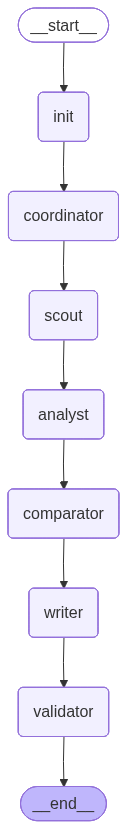

In [9]:
builder = StateGraph(VeilleState)

builder.add_node("init", init_node)
builder.add_node("coordinator", coordinator_node)
builder.add_node("scout", scout_node)
builder.add_node("analyst", analyst_node)
builder.add_node("comparator", comparator_node)
builder.add_node("writer", writer_node)
builder.add_node("validator", validator_node)

builder.set_entry_point("init")
builder.add_edge("init", "coordinator")
builder.add_edge("coordinator", "scout")
builder.add_edge("scout", "analyst")
builder.add_edge("analyst", "comparator")
builder.add_edge("comparator", "writer")
builder.add_edge("writer", "validator")

builder.add_conditional_edges("validator", validation_router)

workflow = builder.compile()
print("Workflow compilé")

display(Image(workflow.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {
    "topic": TARGET_TOPIC,
    "logs": [],
    "validation": ""
}

config = {"configurable": {"thread_id": "veille_001"}}

final_state = workflow.invoke(initial_state, config=config)

print("\n--- RAPPORT FINAL ---")
print(final_state["final_report"][:500] + "...\n(Aperçu tronqué)")

report_path = f"{REPORTS_DIR}/report_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(final_state["final_report"])

print(f"\nRapport Markdown enregistré : {report_path}")

[COORDINATOR]
[SCOUT]
[ANALYST]
[COMPARATOR]
[WRITER]
[VALIDATOR]
Rapport validé

--- RAPPORT FINAL ---
# RAPPORT STRATEGIQUE IA  

## Executive Summary  
Le projet SMA dispose déjà d’une base technique solide (LangGraph, ChromaDB, PoC d’évaluateur d’hallucinations). Cependant, six écarts majeurs freinent la mise en production prévue pour **septembre 2026** : absence de gouvernance IA automatisée, non‑déploiement d’AutoGen, manque de métriques de qualité, absence de suivi budgétaire en temps réel, inexistence d’infrastructure‑as‑code (IaC) et de pipeline CI/CD, et absence de solution RAG‑as‑a‑Serv...
(Aperçu tronqué)

Rapport Markdown enregistré : reports/report_20260520_0042.md


In [11]:
# EXPORT PDF 
pdfmetrics.registerFont(TTFont('DejaVu', 'DejaVuSans.ttf'))

styles = getSampleStyleSheet()
styles["BodyText"].fontName = "DejaVu"
styles["BodyText"].leading = 14
styles["Heading1"].fontName = "DejaVu"
styles["Heading2"].fontName = "DejaVu"
styles["Heading3"].fontName = "DejaVu"
styles.add(ParagraphStyle(name='TableText', parent=styles['BodyText'], fontSize=9, leading=12))

pdf_path = report_path.replace(".md", ".pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=A4, rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=30)
story = []

report_md = final_state["final_report"].replace("–", "-").replace("—", "-").replace("<br>", "\n")
lines = report_md.split("\n")

in_table = False
table_data = []

def flush_table():
    global in_table, table_data
    if in_table and table_data:
        max_cols = max(len(row) for row in table_data)
        for row in table_data:
            while len(row) < max_cols:
                row.append(Paragraph("", styles["TableText"]))
                
        col_width = 515.0 / max_cols
        t = Table(table_data, colWidths=[col_width] * max_cols)
        t.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#ecf0f1')),
            ('TEXTCOLOR',(0,0),(-1,-1),colors.black),
            ('ALIGN', (0,0), (-1,-1), 'LEFT'),
            ('VALIGN', (0,0), (-1,-1), 'TOP'),
            ('FONTNAME', (0,0),(-1,-1), 'DejaVu'),
            ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#bdc3c7')),
            ('BOTTOMPADDING', (0,0), (-1,-1), 8),
            ('TOPPADDING', (0,0), (-1,-1), 8),
            ('LEFTPADDING', (0,0), (-1,-1), 6),
            ('RIGHTPADDING', (0,0), (-1,-1), 6),
        ]))
        story.append(t)
        story.append(Spacer(1, 15))
    in_table = False
    table_data = []

for line in lines:
    line = line.strip()
    line = re.sub(r"\*\*(.*?)\*\*", r"<b>\1</b>", line)

    if "|" in line:
        if "---" in line: continue
        cells = line.split("|")
        if cells and cells[0].strip() == "": cells = cells[1:]
        if cells and cells[-1].strip() == "": cells = cells[:-1]
        
        row = [Paragraph(c.strip(), styles["TableText"]) for c in cells]
        table_data.append(row)
        in_table = True
        continue
    else:
        flush_table()

    if not line:
        story.append(Spacer(1, 10))
        continue
    
    if line.startswith("# "):
        story.append(Paragraph(f"<font size=20 color='#2c3e50'><b>{line.replace('# ', '')}</b></font>", styles["Heading1"]))
        story.append(Spacer(1, 18))
    elif line.startswith("## "):
        story.append(Paragraph(f"<font size=16 color='#2980b9'><b>{line.replace('## ', '')}</b></font>", styles["Heading2"]))
        story.append(Spacer(1, 14))
    elif line.startswith("### "):
        story.append(Paragraph(f"<font size=13 color='#34495e'><b>{line.replace('### ', '')}</b></font>", styles["Heading3"]))
        story.append(Spacer(1, 10))
    elif line.startswith("- ") or line.startswith("* "):
        story.append(Paragraph(f"• {line[2:]}", styles["BodyText"]))
        story.append(Spacer(1, 5))
    else:
        story.append(Paragraph(line, styles["BodyText"]))
        story.append(Spacer(1, 8))

flush_table()
doc.build(story)
print(f"PDF généré avec succès :\n{pdf_path}")

PDF généré avec succès :
reports/report_20260520_0042.pdf


In [ ]:
conn = sqlite3.connect("veille_history.db")
cursor = conn.cursor()
cursor.execute("""
CREATE TABLE IF NOT EXISTS history (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    topic TEXT,
    created_at TEXT,
    report TEXT
)
""")

cursor.execute(
    "INSERT INTO history (topic, created_at, report) VALUES (?, ?, ?)",
    (TARGET_TOPIC, datetime.datetime.now().isoformat(), final_state["final_report"])
)
conn.commit()
conn.close()
print("Historique sauvegardé dans SQLite")


Historique sauvegardé dans SQLite


'\n# Décommenter pour activer le lancement automatique toutes les 6 heures\ndef scheduled_cycle():\n    print("NOUVEAU CYCLE AUTOMATIQUE")\n    workflow.invoke({"topic": TARGET_TOPIC, "logs": [], "validation": ""}, config=config)\n\nscheduler = BackgroundScheduler()\nscheduler.add_job(scheduled_cycle, "interval", hours=6)\nscheduler.start()\nprint("Scheduler démarré")\n'

In [ ]:
#pour activer le lancement automatique toutes les 6 heures
def scheduled_cycle():
    print("NOUVEAU CYCLE AUTOMATIQUE")
    workflow.invoke({"topic": TARGET_TOPIC, "logs": [], "validation": ""}, config=config)

scheduler = BackgroundScheduler()
scheduler.add_job(scheduled_cycle, "interval", hours=6)
scheduler.start()
print("Scheduler démarré")